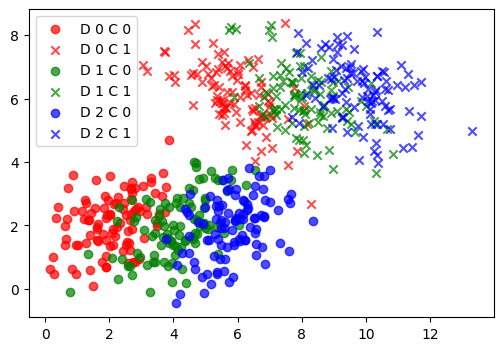

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
np.random.seed(42)

# Set seed for reproducibility
np.random.seed(42)

def generate_gaussian_data(mean, cov, num_samples, label):
    """Generate data from a multivariate Gaussian distribution."""
    data = np.random.multivariate_normal(mean, cov, num_samples)
    labels = np.full(num_samples, label)
    return data, labels

# Define the parameters for the three domains
# Shift the means between domains but keep covariances similar to simulate covariate shift
domains = [
    {"mean_class_0": [2, 2], "mean_class_1": [6, 6], 
     "cov_class_0": [[1, 0.5], [0.5, 1]], "cov_class_1": [[1, -0.5], [-0.5, 1]]},
    
    {"mean_class_0": [4, 2], "mean_class_1": [8, 6], 
     "cov_class_0": [[1, 0.5], [0.5, 1]], "cov_class_1": [[1, -0.5], [-0.5, 1]]},
    
    {"mean_class_0": [6, 2], "mean_class_1": [10, 6], 
     "cov_class_0": [[1, 0.5], [0.5, 1]], "cov_class_1": [[1, -0.5], [-0.5, 1]]}
]

# Generate data for each domain
domain_data = []
domain_labels = []
num_samples_per_class = 100

for domain in domains:
    data_class_0, labels_class_0 = generate_gaussian_data(domain["mean_class_0"], domain["cov_class_0"], num_samples_per_class, label=0)
    data_class_1, labels_class_1 = generate_gaussian_data(domain["mean_class_1"], domain["cov_class_1"], num_samples_per_class, label=1)
    
    domain_data.append(np.vstack([data_class_0, data_class_1]))
    domain_labels.append(np.hstack([labels_class_0, labels_class_1]))

# Prepare the training data (from Domain 1 and Domain 2)
X_train = np.vstack([domain_data[0], domain_data[1]])
y_train = np.hstack([domain_labels[0], domain_labels[1]])

# Prepare the test data (from Domain 3)
X_test = domain_data[2]
y_test = domain_labels[2]

# Visualize the data to check the covariate shift across domains
colors = ['r', 'g', 'b']
plt.figure(figsize=(6, 4))
for i, (data, labels) in enumerate(zip(domain_data, domain_labels)):
    plt.scatter(data[labels == 0][:, 0], data[labels == 0][:, 1], label=f"D {i} C 0", alpha=0.7, color=colors[i], marker='o')
    plt.scatter(data[labels == 1][:, 0], data[labels == 1][:, 1], label=f"D {i} C 1", alpha=0.7, color=colors[i], marker='x')

plt.legend()
# plt.title('Covariate Shift Across Domains for Class 0 and Class 1')
# plt.show()
plt.savefig("syntheticdata.pdf")

In [2]:
# Convert data to PyTorch tensors
X_train_tensor = torch.Tensor(X_train)
y_train_tensor = torch.Tensor(y_train).long()
X_test_tensor = torch.Tensor(X_test)
y_test_tensor = torch.Tensor(y_test).long()

In [3]:

# Define the MLP model
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleMLP, self).__init__()
        self.featurizer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(hidden_size, 2)
    
    def forward(self, x):
        features = self.featurizer(x)
        logits = self.classifier(features)
        return logits, features


In [4]:
# Initialize model, loss function, and optimizer
input_size = X_train.shape[1]
hidden_size = 16
output_size = 2
model_a = SimpleMLP(input_size, hidden_size, output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_a.parameters(), lr=0.001)

# Training the model on first two domains
num_epochs = 100
for epoch in range(num_epochs):
    model_a.train()
    outputs, _ = model_a(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")



Epoch [10/100], Loss: 0.6811
Epoch [20/100], Loss: 0.6494
Epoch [30/100], Loss: 0.6176
Epoch [40/100], Loss: 0.5851
Epoch [50/100], Loss: 0.5534
Epoch [60/100], Loss: 0.5200
Epoch [70/100], Loss: 0.4819
Epoch [80/100], Loss: 0.4457
Epoch [90/100], Loss: 0.4115
Epoch [100/100], Loss: 0.3784


In [5]:
accs = []
for i in range(10):
    # Evaluate the model on the third domain
    model_a.eval()
    with torch.no_grad():
        test_outputs, _ = model_a(X_test_tensor)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_tensor).float().mean()
        accs.append(accuracy.item())
        
print(f"Test Accuracy on third domain: {np.mean(accs) * 100:.2f}%")

Test Accuracy on third domain: 92.00%


In [6]:
def rbf_kernel(features, gamma=None):
    """Compute the RBF (Gaussian) kernel matrix."""
    pairwise_sq_dists = torch.cdist(features, features, p=2).pow(2)
    if gamma is None:
        gamma = 1.0 / features.size(1)  # Default gamma is 1 / feature_dim
    kernel = torch.exp(-gamma * pairwise_sq_dists)
    return kernel

def diversity_loss(features, gamma=0.03):
    """Compute the DPP-based diversity loss."""
    kernel_matrix = rbf_kernel(features, gamma=gamma)
    # Add a small value to the diagonal for numerical stability
    kernel_matrix += torch.eye(kernel_matrix.size(0)).to(features.device) * 1e-6
    loss = -torch.logdet(kernel_matrix)
    return loss

In [7]:
X_train.shape

(400, 2)

In [8]:
# Initialize model, loss function, and optimizer
input_size = X_train.shape[1]
hidden_size = 64
output_size = 2
model_b = SimpleMLP(input_size, hidden_size, output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_b.parameters(), lr=0.001)

# Set the weight for the DPP regularization term
alpha = 0.5  # You can adjust this value

# Training the model on first two domains with DPP regularization
num_epochs = 100
for epoch in range(num_epochs):
    model_b.train()

    # Forward pass
    outputs, feats = model_b(X_train_tensor)
    # Compute cross-entropy loss
    loss_ce = criterion(outputs, y_train_tensor)
    # Compute diversity loss using DPP regularization
    loss_dpp = diversity_loss(X_train_tensor, gamma=0.1)

    # Combine cross-entropy loss with diversity loss
    loss = alpha * loss_ce + (1- alpha) * loss_dpp

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: nan
Epoch [20/100], Loss: nan
Epoch [30/100], Loss: nan
Epoch [40/100], Loss: nan
Epoch [50/100], Loss: nan
Epoch [60/100], Loss: nan
Epoch [70/100], Loss: nan
Epoch [80/100], Loss: nan
Epoch [90/100], Loss: nan
Epoch [100/100], Loss: nan


In [9]:
feats.shape

torch.Size([400, 64])

In [10]:
accs2 = []
for i in range(10):
    # Evaluate the model on the third domain
    model_b.eval()
    with torch.no_grad():
        test_outputs, _ = model_b(X_test_tensor)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = (predicted == y_test_tensor).float().mean()
        accs2.append(accuracy.item())
print(f"Test Accuracy on third domain: {np.mean(accs2) * 100:.2f}%")
        

Test Accuracy on third domain: 98.00%


/tmp/ipykernel_2490179/2273153547.py:51: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="1", edgecolors='k', color='black', marker='x', alpha=0.9)


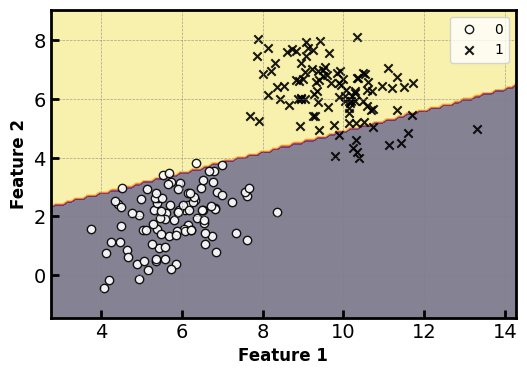

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assuming the model has been trained and Domain 3 is the test data
# Define a mesh grid based on the test data range
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
plt.figure(figsize=(6, 4))
# Flatten the grid to pass through the model
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.Tensor(grid)

# Get the model's predictions for each point in the grid
model_a.eval()
with torch.no_grad():
    Z, _ = model_a(grid_tensor)
    _, Z = torch.max(Z, 1)  # Get the predicted class (0 or 1)
    Z = Z.reshape(xx.shape)  # Reshape to match the mesh grid shape

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.inferno)

# Customize axes appearance
ax = plt.gca()  # Get current axes
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')

# Make spines thicker
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# Bolden and darken the ticks
ax.tick_params(axis='both', colors='black', direction='in', length=6, width=2, labelsize=14)

# Add axis labels and title
plt.xlabel("X-axis", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Y-axis", fontsize=12, fontweight='bold', color='black')

# Optionally add or modify grid lines
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Plot the test data points (Domain 3)
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], label="0", edgecolors='k', color='white', marker='o', alpha=0.9)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="1", edgecolors='k', color='black', marker='x', alpha=0.9)

# Formatting
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
# plt.title('Decision Boundary on Domain 3 (Test Domain)')
plt.savefig("modela.pdf")


/tmp/ipykernel_2490179/2344483982.py:51: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="1", edgecolors='k', color='black', marker='x', alpha=0.9)


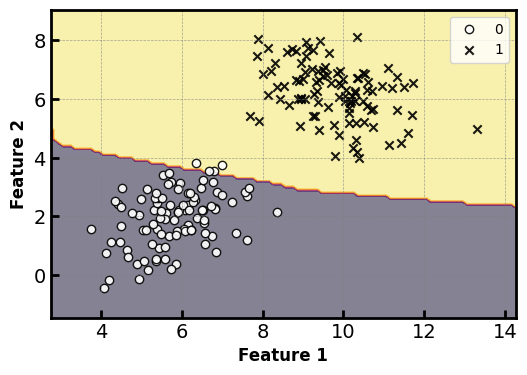

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assuming the model has been trained and Domain 3 is the test data
# Define a mesh grid based on the test data range
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Flatten the grid to pass through the model
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.Tensor(grid)
plt.figure(figsize=(6, 4))
# Get the model's predictions for each point in the grid
model_b.eval()
with torch.no_grad():
    Z, _ = model_b(grid_tensor)
    _, Z = torch.max(Z, 1)  # Get the predicted class (0 or 1)
    Z = Z.reshape(xx.shape)  # Reshape to match the mesh grid shape

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.inferno)

# Customize axes appearance
ax = plt.gca()  # Get current axes
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')

# Make spines thicker
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# Bolden and darken the ticks
ax.tick_params(axis='both', colors='black', direction='in', length=6, width=2, labelsize=14)

# Add axis labels and title
plt.xlabel("X-axis", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Y-axis", fontsize=12, fontweight='bold', color='black')

# Optionally add or modify grid lines
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Plot the test data points (Domain 3)
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], label="0", edgecolors='k', color='white', marker='o', alpha=0.9)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], label="1", edgecolors='k', color='black', marker='x', alpha=0.9)

# Formatting
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
# plt.title('Decision Boundary on Domain 3 (Test Domain)')
plt.savefig("modelb.pdf")
